# Peak-productivity windows
Explains how each peak-productivity window was dated and at what age individuals flourished.

In [1]:
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import gaussian_kde

SEED = 42
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CV_DB_PATH = '../data/similar_databases/cross_verified.duckdb'
PRODUCTIVE_AGE_CSV = '../data/productive_age_window.csv'
YEAR_OR_FINER = ('day', 'month', 'year')
BIN_WIDTH = 50
LAST_COMPLETE_BIN = 1950

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(220)

METHOD_COLORS = {
    'Floruit (P1317)': '#c46a5a',
    'Works span': '#5b8fc7',
    'Single work': '#a9cbe8',
    'Birth + death': '#e39b5b',
    'Birth only': '#f3cf9f',
    'Death only': '#b3a2d1',
    'No window': '#d3d7dc',
}
OCCUPATION_COLORS = {
    'Culture': '#5b8fc7',
    'Discovery/Science': '#6fb07f',
    'Leadership': '#e39b5b',
    'Sports/Games': '#a58cc7',
}
ERA_COLORS = {
    'before 500': '#c46a5a',
    '500 – 1500': '#e39b5b',
    '1500 – 1800': '#6fb07f',
    '1800 – 1900': '#5b8fc7',
    'after 1900': '#a58cc7',
}
LINE_COLOR = '#3f6f9f'
BAND_COLOR = '#5b8fc7'
GRID_COLOR = '#ececec'

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (11, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'axes.formatter.useoffset': False,
})
THOUSANDS = FuncFormatter(lambda x, _: f'{x:,.0f}')

## External data — Cross-Verified occupations, productive-age CSV

In [2]:
cv_con = duckdb.connect(CV_DB_PATH, read_only=True)
cv_occupations = cv_con.sql("""
    SELECT
        wikidata_code AS qid,
        level1_main_occ
    FROM individuals
    WHERE wikidata_code IS NOT NULL
      AND level1_main_occ IS NOT NULL
""").pl()
cv_con.close()
assert cv_occupations['qid'].n_unique() == cv_occupations.height
print('cv_occupations:', cv_occupations.shape)

productive_age_window = pl.read_csv(PRODUCTIVE_AGE_CSV)
productive_age_window

cv_occupations: (2291817, 2)


category,individuals,low_age,median_age,high_age,measured_on
str,i64,i64,i64,i64,str
"""global""",16106,29,39,53,"""2026-09-23"""
"""Culture""",3139,30,43,61,"""2026-09-23"""
"""Discovery/Science""",349,32,45,60,"""2026-09-23"""
"""Leadership""",308,30,44,58,"""2026-09-23"""
"""Sports/Games""",222,21,27,35,"""2026-09-23"""
"""Other""",64,26,43,54,"""2026-09-23"""
"""Missing""",10,36,46,59,"""2026-09-23"""


## Load data

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")
con.sql("CREATE TEMP MACRO from_llm(d) AS coalesce(d.field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates', false)")

### Assignation-method counts

In [4]:
method_stats = con.sql("""
    SELECT
        peak_productivity.assignation_method  AS method,
        count(*)                              AS n,
        round(avg(peak_productivity.end_year - peak_productivity.start_year), 1)                     AS mean_width,
        count(*) FILTER (WHERE peak_productivity.end_year - peak_productivity.start_year > 100)      AS wide_windows
    FROM individual_enriched
    GROUP BY method
    ORDER BY n DESC
""").pl()
TOTAL_INDIVIDUALS = method_stats['n'].sum()
print(f'individuals: {TOTAL_INDIVIDUALS:,}')
method_stats

individuals: 13,002,897


method,n,mean_width,wide_windows
str,i64,f64,i64
"""birth_only_wikidata_property""",3681457,20.0,0
null,3293369,null,0
"""birth_death_wikidata_property""",2887719,21.6,0
"""works_span""",1663350,12.1,7630
"""works_single""",1111551,10.7,0
"""death_only_wikidata_property""",298218,24.0,0
"""floruit_wikidata_property""",67233,25.9,384


### Windows per method and bucket

In [5]:
method_by_bucket = con.sql("""
    SELECT
        peak_productivity.assignation_method AS method,
        floor((peak_productivity.start_year + peak_productivity.end_year) / 2 / $bin_width) * $bin_width AS bucket,
        count(*) AS n
    FROM individual_enriched
    WHERE peak_productivity.assignation_method IS NOT NULL
    GROUP BY method, bucket
""", params={'bin_width': BIN_WIDTH}).pl().with_columns(pl.col('bucket').cast(pl.Int64))
assert method_by_bucket['n'].sum() == method_stats.filter(pl.col('method').is_not_null())['n'].sum()
method_by_bucket.sort('n', descending=True).head()

method,bucket,n
str,i64,i64
"""birth_only_wikidata_property""",2000,2091486
"""works_span""",2000,1479308
"""birth_only_wikidata_property""",1950,1163709
"""works_single""",2000,977888
"""birth_death_wikidata_property""",1900,931737


### Worked examples

In [6]:
con.sql("""
    CREATE OR REPLACE TEMP TABLE picked_example AS
    SELECT
        entity.qid                             AS qid,
        entity.label_en                        AS name_en,
        peak_productivity.assignation_method   AS method,
        peak_productivity.start_year           AS start_year,
        peak_productivity.end_year             AS end_year
    FROM individual_enriched
    WHERE entity.label_en IS NOT NULL
    QUALIFY row_number() OVER (PARTITION BY peak_productivity.assignation_method ORDER BY hash(entity.qid)) <= 5
""")

worked_examples = con.sql("""
    SELECT
        p.qid,
        p.name_en,
        p.method,
        p.start_year,
        p.end_year,
        i.birth_date[1].year       AS birth_year,
        i.death_date[1].year       AS death_year,
        i.floruit_date[1].year     AS floruit_date_year,
        i.works_period.first_year  AS works_first,
        i.works_period.last_year   AS works_last
    FROM picked_example AS p
    JOIN individual AS i
      ON i.entity.qid = p.qid
""").pl()
print('shape:', worked_examples.shape)

shape: (35, 10)


### Age at floruit

In [7]:
floruit_birth_pairs = con.sql("""
    SELECT
        entity.qid             AS qid,
        floruit_date[1].year   AS floruit_year,
        birth_date[1].year     AS birth_year
    FROM individual
    WHERE list_contains($year_or_finer, floruit_date[1].precision)
      AND NOT from_llm(floruit_date[1])
      AND list_contains($year_or_finer, birth_date[1].precision)
      AND NOT from_llm(birth_date[1])
""", params={'year_or_finer': list(YEAR_OR_FINER)}).pl()
con.close()

assert floruit_birth_pairs['qid'].n_unique() == floruit_birth_pairs.height
print('shape:', floruit_birth_pairs.shape)
floruit_birth_pairs.head()

shape: (16525, 3)


qid,floruit_year,birth_year
str,i64,i64
"""Q106582465""",1933,1900
"""Q106593712""",1945,1915
"""Q110295343""",1729,1707
"""Q110295485""",1755,1733
"""Q106644110""",1973,1952


## Preprocessing
### Method category

In [8]:
def method_category(col):
    return (
        pl.when(col.is_null()).then(pl.lit('No window'))
        .when(col.str.starts_with('floruit_')).then(pl.lit('Floruit (P1317)'))
        .when(col == 'works_span').then(pl.lit('Works span'))
        .when(col == 'works_single').then(pl.lit('Single work'))
        .when(col.str.starts_with('birth_death_')).then(pl.lit('Birth + death'))
        .when(col.str.starts_with('birth_only_')).then(pl.lit('Birth only'))
        .when(col.str.starts_with('death_only_')).then(pl.lit('Death only'))
        .otherwise(pl.lit('Other'))
    )

METHOD_ORDER = list(METHOD_COLORS)

method_counts = (
    method_stats
    .with_columns(method_category(pl.col('method')).alias('method_category'))
    .group_by('method_category').agg(pl.col('n').sum())
    .with_columns((pl.col('n') / TOTAL_INDIVIDUALS * 100).round(2).alias('share_pct'))
)
assert set(method_counts['method_category']) <= set(METHOD_ORDER)
method_counts.sort('n', descending=True)

method_category,n,share_pct
str,i64,f64
"""Birth only""",3681457,28.31
"""No window""",3293369,25.33
"""Birth + death""",2887719,22.21
"""Works span""",1663350,12.79
"""Single work""",1111551,8.55
"""Death only""",298218,2.29
"""Floruit (P1317)""",67233,0.52


### Method share per bucket

In [9]:
YEAR_MIN = -800

method_share = (
    method_by_bucket
    .filter(pl.col('bucket').is_between(YEAR_MIN, LAST_COMPLETE_BIN))
    .with_columns(method_category(pl.col('method')).alias('method_category'))
    .group_by('bucket', 'method_category').agg(pl.col('n').sum())
    .with_columns((pl.col('n') / pl.col('n').sum().over('bucket')).alias('share'))
    .pivot(values='share', index='bucket', on='method_category')
    .fill_null(0)
    .sort('bucket')
)
for category in METHOD_ORDER[:-1]:
    if category not in method_share.columns:
        method_share = method_share.with_columns(pl.lit(0.0).alias(category))
print('shape:', method_share.shape)
method_share.head()

shape: (56, 7)


bucket,Works span,Death only,Birth + death,Floruit (P1317),Birth only,Single work
i64,f64,f64,f64,f64,f64,f64
-800,0.0,0.254902,0.424837,0.052288,0.24183,0.026144
-750,0.008197,0.418033,0.106557,0.090164,0.377049,0.0
-700,0.004098,0.290984,0.389344,0.057377,0.233607,0.02459
-650,0.013514,0.472973,0.135135,0.141892,0.22973,0.006757
-600,0.019264,0.110333,0.429072,0.096322,0.302977,0.042032


### Worked examples table

In [10]:
(worked_examples
 .with_columns(method_category(pl.col('method')).alias('method_category'))
 .sort(pl.col('method_category').replace_strict({c: i for i, c in enumerate(METHOD_ORDER)}), 'qid')
 .select('method_category', 'method', 'qid', 'name_en', 'birth_year', 'death_year',
         'floruit_date_year', 'works_first', 'works_last', 'start_year', 'end_year'))

method_category,method,qid,name_en,birth_year,death_year,floruit_date_year,works_first,works_last,start_year,end_year
str,str,str,str,i64,i64,i64,i64,i64,i64,i64
"""Floruit (P1317)""","""floruit_wikidata_property""","""Q112822054""","""Hillary Joy Kipnis""",null,null,1987,null,null,1987,2011
"""Floruit (P1317)""","""floruit_wikidata_property""","""Q118430817""","""Rein van Houts""",null,null,1945,null,null,1945,1969
"""Floruit (P1317)""","""floruit_wikidata_property""","""Q130754130""","""Florentius""",null,null,300,null,null,300,324
"""Floruit (P1317)""","""floruit_wikidata_property""","""Q50424072""","""Walter G. Joyce""",null,null,2015,2004,2022,2014,2026
"""Floruit (P1317)""","""floruit_wikidata_property""","""Q98755485""","""Ingela M Grumme""",1950,null,2014,null,null,1979,2014
"""Works span""","""works_span""","""Q124350825""","""Laura D. Baker""",null,null,null,1999,2022,1999,2022
"""Works span""","""works_span""","""Q57250359""","""Akira Yamada""",null,null,null,2006,2023,2006,2023
"""Works span""","""works_span""","""Q57571536""","""Hoda Soleymani Abyaneh""",null,null,null,2017,2018,2017,2018
"""Works span""","""works_span""","""Q61045699""","""Henry H. Bi""",null,null,null,2010,2022,2010,2022


### Age at floruit (10–100 years)

In [11]:
AGE_MIN, AGE_MAX = 10, 100

age_at_floruit = (
    floruit_birth_pairs
    .with_columns((pl.col('floruit_year') - pl.col('birth_year')).alias('age_at_floruit'))
    .filter(pl.col('age_at_floruit').is_between(AGE_MIN, AGE_MAX))
)
print(f'rows: {floruit_birth_pairs.height:,} -> {age_at_floruit.height:,} (kept ages {AGE_MIN}–{AGE_MAX})')
age_at_floruit.head()

rows: 16,525 -> 15,833 (kept ages 10–100)


qid,floruit_year,birth_year,age_at_floruit
str,i64,i64,i64
"""Q106582465""",1933,1900,33
"""Q106593712""",1945,1915,30
"""Q110295343""",1729,1707,22
"""Q110295485""",1755,1733,22
"""Q106644110""",1973,1952,21


In [12]:
SHOW_OCCUPATIONS = list(OCCUPATION_COLORS)

age_at_floruit_by_occupation = (
    age_at_floruit.join(cv_occupations, on='qid', how='inner')
    .filter(pl.col('level1_main_occ').is_in(SHOW_OCCUPATIONS))
)
print(f'matched to a CV occupation: {age_at_floruit_by_occupation.height:,}')
age_at_floruit_by_occupation.group_by('level1_main_occ').len().sort('len', descending=True)

matched to a CV occupation: 3,930


level1_main_occ,len
str,u32
"""Culture""",3074
"""Discovery/Science""",345
"""Leadership""",294
"""Sports/Games""",217


### Productive age per occupation

In [13]:
def quartile_row(df, label):
    ages = df['age_at_floruit']
    return {'category': label, 'n': df.height, 'q1': int(round(ages.quantile(0.25))),
            'median': int(round(ages.median())), 'q3': int(round(ages.quantile(0.75)))}

floruit_media = pl.DataFrame(
    [quartile_row(age_at_floruit, 'global')]
    + [quartile_row(age_at_floruit_by_occupation.filter(pl.col('level1_main_occ') == o), o) for o in SHOW_OCCUPATIONS]
).join(
    productive_age_window.select('category', n_csv='individuals', q1_csv='low_age', median_csv='median_age', q3_csv='high_age'),
    on='category', how='left',
)
floruit_media

category,n,q1,median,q3,n_csv,q1_csv,median_csv,q3_csv
str,i64,i64,i64,i64,i64,i64,i64,i64
"""global""",15833,29,40,54,16106,29,39,53
"""Culture""",3074,30,44,62,3139,30,43,61
"""Discovery/Science""",345,32,45,60,349,32,45,60
"""Leadership""",294,33,45,59,308,30,44,58
"""Sports/Games""",217,22,27,35,222,21,27,35


### Age at floruit per bucket

In [14]:
MIN_BIN_N = 10

def age_per_bucket(df, by=()):
    return (
        df.filter(pl.col('floruit_year') < LAST_COMPLETE_BIN + BIN_WIDTH)
        .with_columns((pl.col('floruit_year') // BIN_WIDTH * BIN_WIDTH).alias('bucket'))
        .group_by(*by, 'bucket')
        .agg(pl.len().alias('n'),
             pl.col('age_at_floruit').median().alias('median'),
             pl.col('age_at_floruit').quantile(0.25).alias('q25'),
             pl.col('age_at_floruit').quantile(0.75).alias('q75'))
        .filter(pl.col('n') >= MIN_BIN_N)
        .sort(*by, 'bucket')
    )

age_per_century = age_per_bucket(age_at_floruit)
age_per_bin_by_occupation = age_per_bucket(age_at_floruit_by_occupation, by=('level1_main_occ',))
print('overall:', age_per_century.shape, '| per occupation:', age_per_bin_by_occupation.shape)
age_per_century.head()

overall: (14, 5) | per occupation: (24, 6)


bucket,n,median,q25,q75
i64,u32,f64,f64,f64
1250,10,49.5,21.0,60.0
1350,12,29.5,21.0,30.0
1400,22,35.0,27.0,54.0
1450,35,43.0,32.0,56.0
1500,62,34.5,25.0,55.0


## Figures
### Fig 1 — Assignation methods

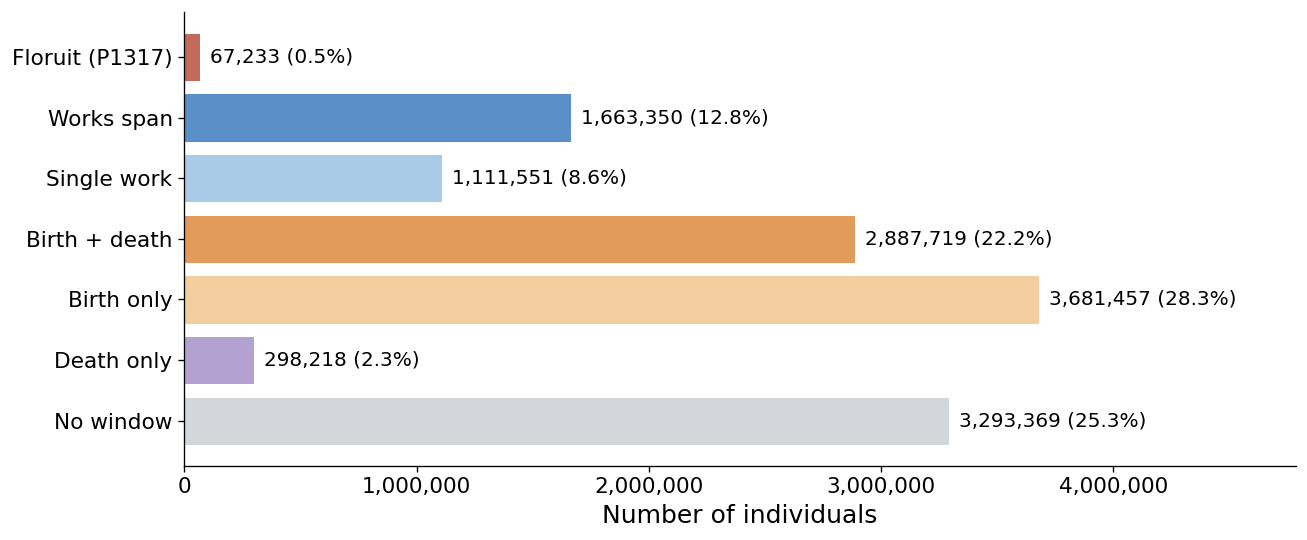

In [15]:
counts_for_plot = (
    pl.DataFrame({'method_category': METHOD_ORDER[::-1]})
    .join(method_counts, on='method_category', how='left')
    .fill_null(0)
)
labels = counts_for_plot['method_category'].to_list()

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.barh(labels, counts_for_plot['n'], color=[METHOD_COLORS[l] for l in labels], edgecolor='white', lw=0.6)
for y, (n, share) in enumerate(zip(counts_for_plot['n'], counts_for_plot['share_pct'])):
    ax.annotate(f'{n:,} ({share:.1f}%)', xy=(n, y), xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=12)
ax.xaxis.set_major_formatter(THOUSANDS)
ax.set_xlabel('Number of individuals')
ax.margins(x=0.30)
plt.tight_layout()
plt.show()

### Fig 2 — Method share over time

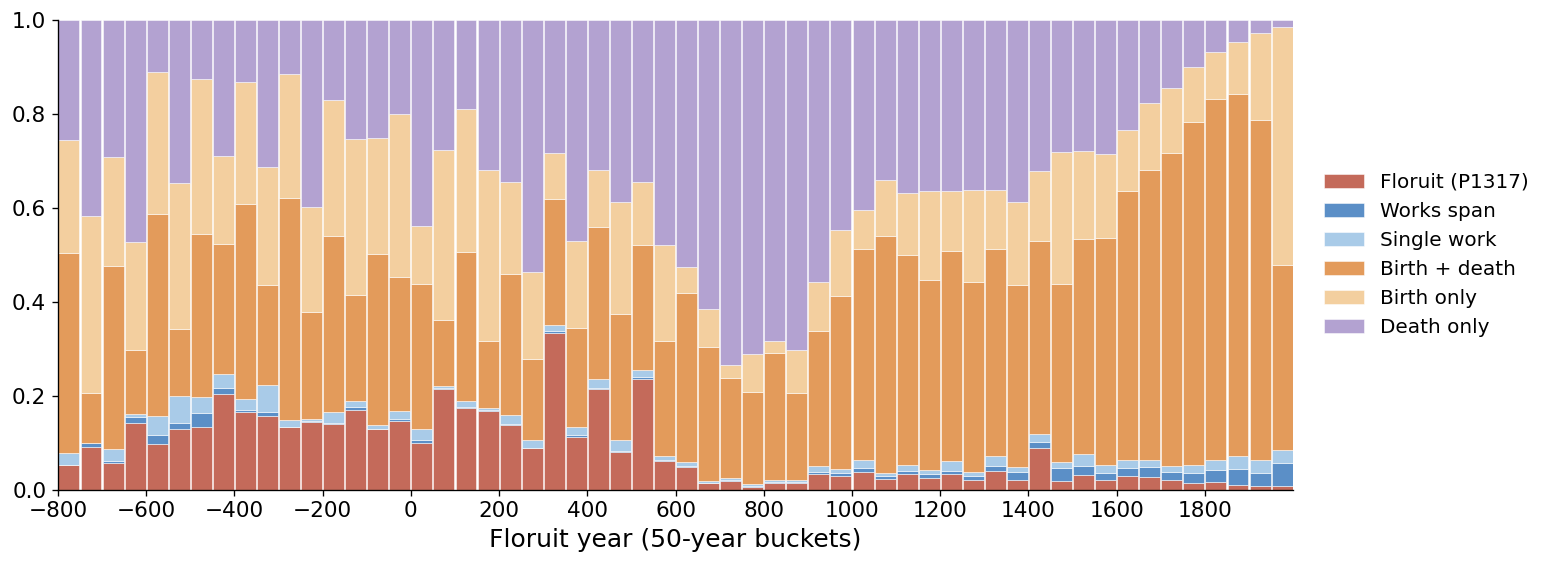

In [16]:
buckets = method_share['bucket'].to_numpy()

fig, ax = plt.subplots(figsize=(13, 4.8))
bottom = np.zeros(len(buckets))
for category in METHOD_ORDER[:-1]:
    share = method_share[category].to_numpy()
    ax.bar(buckets + BIN_WIDTH / 2, share, bottom=bottom, width=BIN_WIDTH * 0.95,
           color=METHOD_COLORS[category], edgecolor='white', lw=0.3, label=category)
    bottom += share
ax.set_xticks(np.arange(YEAR_MIN, LAST_COMPLETE_BIN + 1, 200))
ax.set_xlim(YEAR_MIN, LAST_COMPLETE_BIN + BIN_WIDTH)
ax.set_ylim(0, 1)
ax.set_xlabel('Floruit year (50-year buckets)')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

### Fig 3 — Age at floruit by era

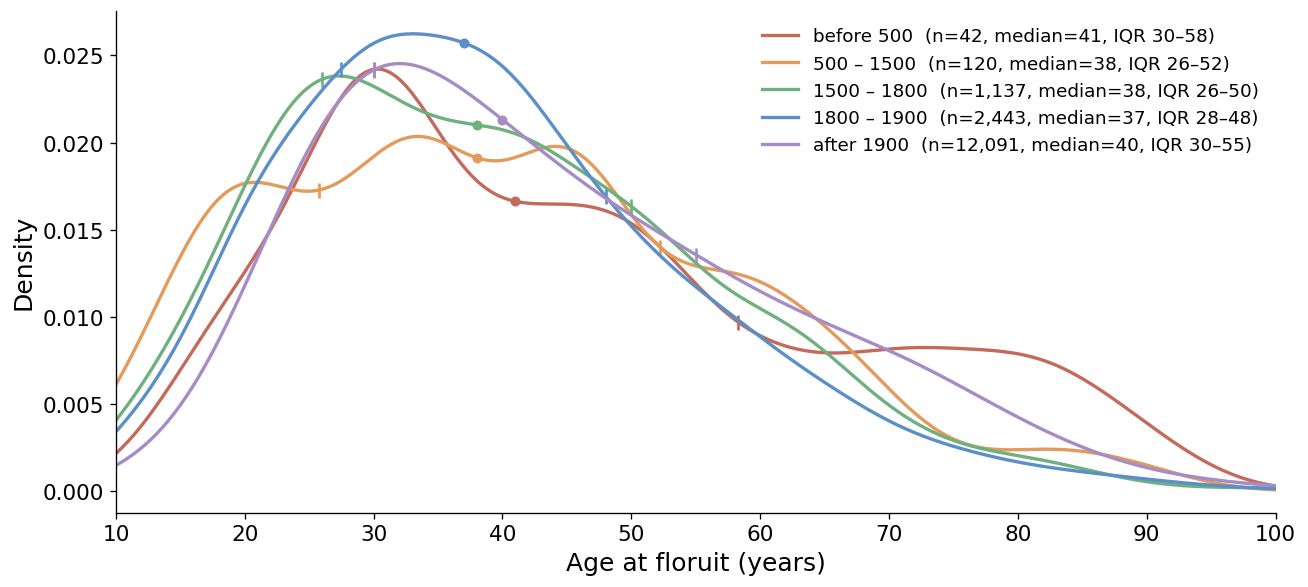

In [17]:
ERAS = [('before 500', None, 500), ('500 – 1500', 500, 1500), ('1500 – 1800', 1500, 1800),
        ('1800 – 1900', 1800, 1900), ('after 1900', 1900, None)]
KDE_BANDWIDTH = 0.25
x_grid = np.linspace(AGE_MIN, AGE_MAX, 400)

def plot_kde(ax, ages, color, label):
    kde = gaussian_kde(ages, bw_method=KDE_BANDWIDTH)
    median, q1, q3 = np.median(ages), np.quantile(ages, 0.25), np.quantile(ages, 0.75)
    ax.plot(x_grid, kde(x_grid), color=color, lw=2,
            label=f'{label}  (n={len(ages):,}, median={median:.0f}, IQR {q1:.0f}–{q3:.0f})')
    ax.plot([median], kde(median), 'o', color=color, ms=5)
    ax.plot([q1, q3], kde([q1, q3]), '|', color=color, ms=9, mew=1.6)

fig, ax = plt.subplots()
for label, lo, hi in ERAS:
    year = pl.col('floruit_year')
    cond = (year >= (lo if lo is not None else -10**6)) & (year < (hi if hi is not None else 10**6))
    ages = age_at_floruit.filter(cond)['age_at_floruit'].to_numpy()
    if len(ages) >= 5:
        plot_kde(ax, ages, ERA_COLORS[label], label)
ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

### Fig 4 — Age at floruit by occupation

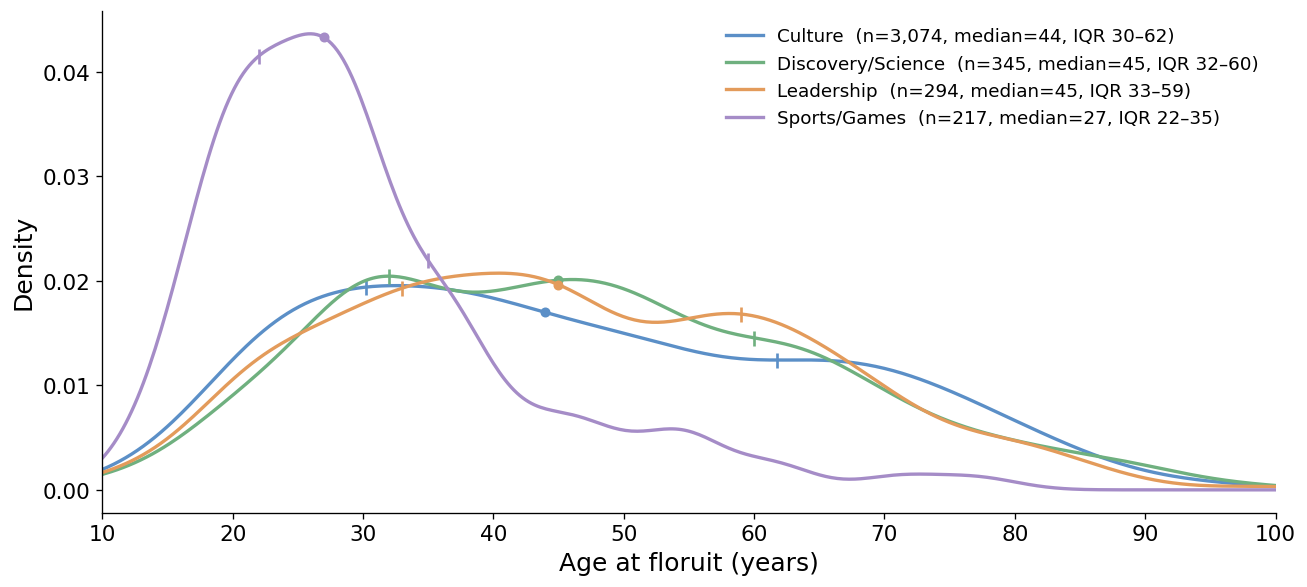

In [18]:
fig, ax = plt.subplots()
for occupation, color in OCCUPATION_COLORS.items():
    ages = age_at_floruit_by_occupation.filter(pl.col('level1_main_occ') == occupation)['age_at_floruit'].to_numpy()
    if len(ages) >= 5:
        plot_kde(ax, ages, color, occupation)
ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

### Fig 5 — Age at floruit over time

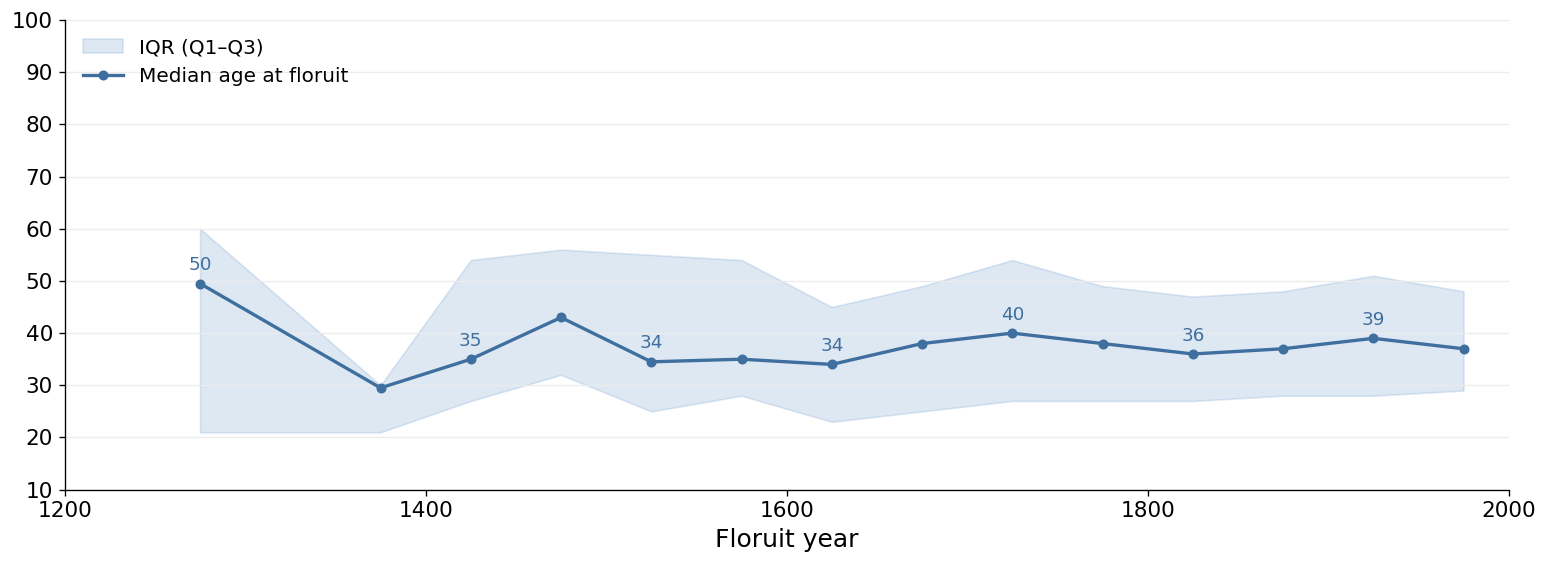

In [19]:
xs = age_per_century['bucket'].to_numpy() + BIN_WIDTH / 2
median = age_per_century['median'].to_numpy()

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.fill_between(xs, age_per_century['q25'], age_per_century['q75'], color=BAND_COLOR, alpha=0.2, label='IQR (Q1–Q3)')
ax.plot(xs, median, color=LINE_COLOR, lw=2, marker='o', ms=5, label='Median age at floruit')
for i, (x, m) in enumerate(zip(xs, median)):
    if i % 2 == 0:
        ax.annotate(f'{m:.0f}', (x, m), xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=11, color=LINE_COLOR)
first = int(age_per_century['bucket'].min() // 100 * 100)
ax.set_xticks(range(first, LAST_COMPLETE_BIN + BIN_WIDTH + 1, 200))
ax.set_xlim(first, LAST_COMPLETE_BIN + BIN_WIDTH)
ax.set_ylim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Floruit year')
ax.grid(axis='y', color=GRID_COLOR, lw=0.8)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

### Fig 6 — Age at floruit over time, by occupation

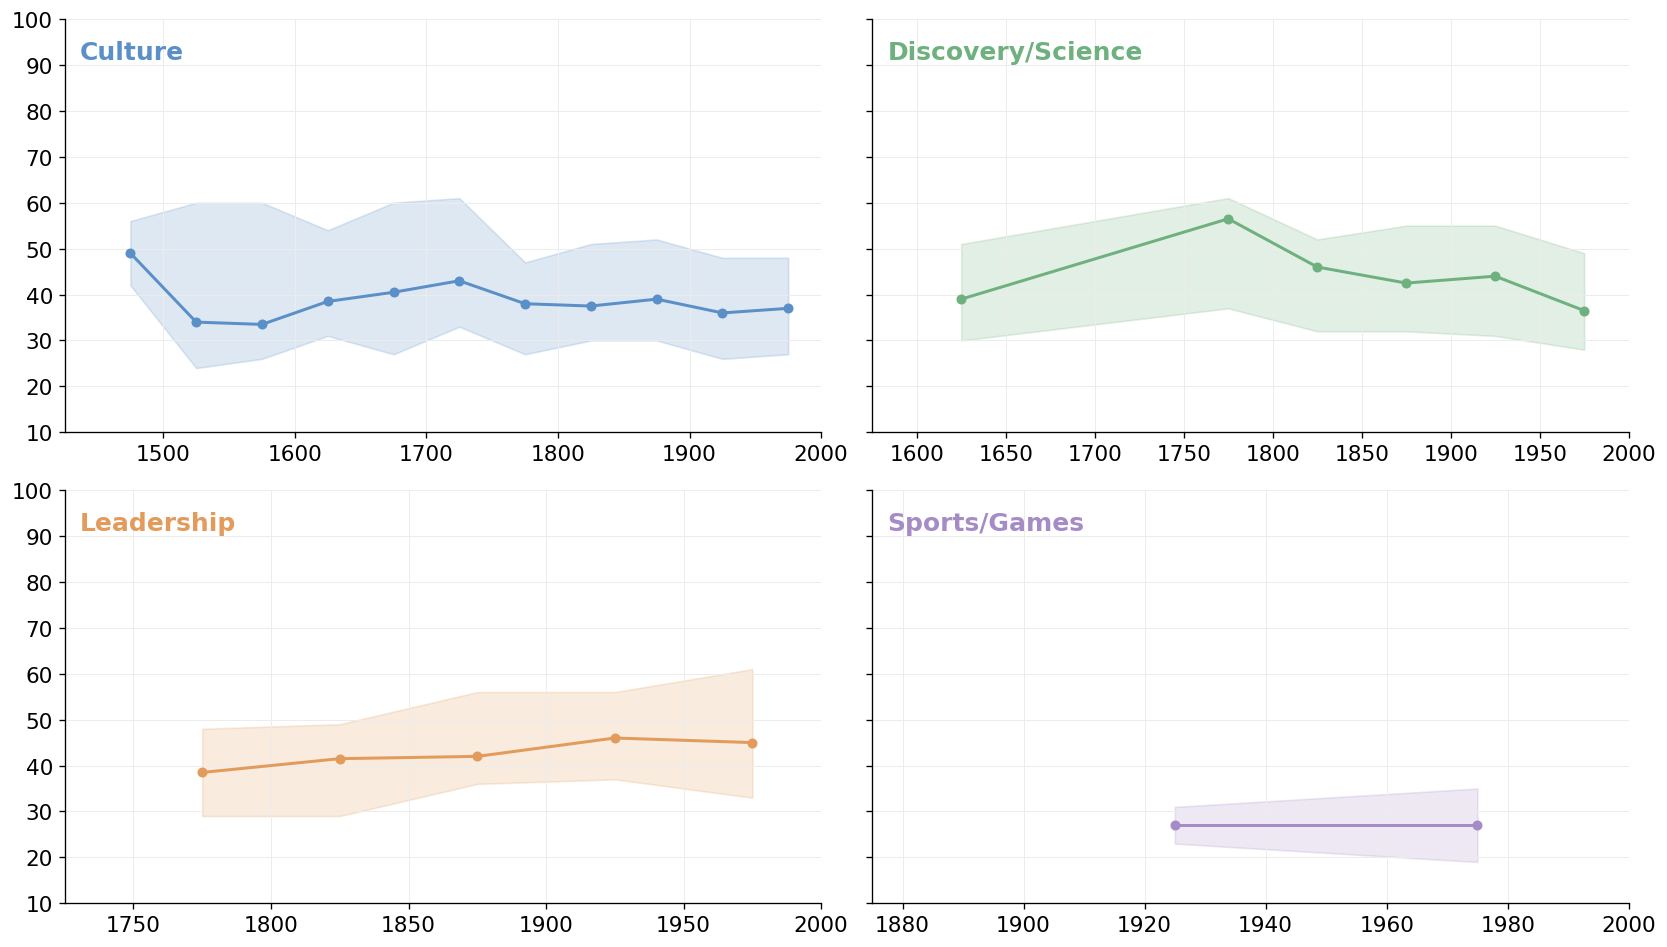

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, (occupation, color) in zip(axes.flat, OCCUPATION_COLORS.items()):
    sub = age_per_bin_by_occupation.filter(pl.col('level1_main_occ') == occupation)
    x = sub['bucket'].to_numpy() + BIN_WIDTH / 2
    ax.fill_between(x, sub['q25'], sub['q75'], color=color, alpha=0.2)
    ax.plot(x, sub['median'], color=color, lw=1.8, marker='o', ms=5)
    ax.set_xlim(x.min() - BIN_WIDTH, LAST_COMPLETE_BIN + BIN_WIDTH)
    ax.set_ylim(AGE_MIN, AGE_MAX)
    ax.text(0.02, 0.95, occupation, transform=ax.transAxes, fontsize=15, color=color, va='top', fontweight='bold')
    ax.grid(True, color=GRID_COLOR, lw=0.6)
plt.tight_layout()
plt.show()